# The Goal of this Notebook is to implement CNN from scratch and reduce Overfitting by using Data Augmentation , Batch Normalization and Dropout

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dogs-vs-cats/test1.zip
/kaggle/input/dogs-vs-cats/train.zip
/kaggle/input/dogs-vs-cats/sampleSubmission.csv


In [5]:
# Creating a project folder
import os
os.makedirs('/kaggle/working/dogs-vs-cats', exist_ok=True)


I created a directory named dogs-vs-cats inside kaggle's working directory and set exist_ok = True ensures no error if the folder already exists.

In [6]:
# Unzip the train.zip file
import zipfile

with zipfile.ZipFile('/kaggle/input/dogs-vs-cats/train.zip', 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/dogs-vs-cats')


just opened the train.zip from kaggle's input directory and extracted all training images into my working directory

In [7]:
os.listdir('/kaggle/working/dogs-vs-cats')


['train']

In [8]:
os.listdir('/kaggle/working/dogs-vs-cats/train')[:5]


['cat.6812.jpg', 'dog.777.jpg', 'cat.3693.jpg', 'cat.478.jpg', 'cat.3039.jpg']

In [9]:
# Creating a class folder
base_dir = '/kaggle/working/dogs-vs-cats/train'

os.makedirs(base_dir + '/cats', exist_ok=True)
os.makedirs(base_dir + '/dogs', exist_ok=True)


created subdirectories per class 

In [10]:
# Moving images into correct folders
import shutil

for file in os.listdir(base_dir):
    path = os.path.join(base_dir, file)

    if os.path.isdir(path):
        continue

    if file.startswith('cat'):
        shutil.move(path, base_dir + '/cats/' + file)
    elif file.startswith('dog'):
        shutil.move(path, base_dir + '/dogs/' + file)


Looping through all files in trian/ and moves cat*.jpg -> cats/ and dog*.jpg -> dogs/ 

In [11]:
os.listdir('/kaggle/working/dogs-vs-cats/train')


['dogs', 'cats']

In [12]:
#Unzip test.zip file
import zipfile, os

os.makedirs('/kaggle/working/dogs-vs-cats/test', exist_ok=True)

with zipfile.ZipFile('/kaggle/input/dogs-vs-cats/test1.zip', 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/dogs-vs-cats/test')


Created a test directory and extracted test images which are unlabeled

In [13]:
# Creating training and validation dataset
import tensorflow as tf

DATA_DIR = '/kaggle/working/dogs-vs-cats/train'

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(256, 256),
    batch_size=64,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='training',
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(256, 256),
    batch_size=32,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=42
)


Found 25000 files belonging to 2 classes.
Using 20000 files for training.


I0000 00:00:1770114020.331670      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770114020.337702      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [14]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D , MaxPooling2D , GlobalAveragePooling2D , Dense , BatchNormalization , Dropout

In [15]:
# Keras preprocessing layers 
# Resizing and Rescaling 
IMG_SIZE = 160

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMG_SIZE , IMG_SIZE),
    layers.Rescaling(1./255)
])

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomWidth(0.1),
    tf.keras.layers.RandomHeight(0.1),
])

# Making the preprocessing layers part of our model
model = Sequential([
    tf.keras.Input(shape=(256,256,3)),
    resize_and_rescale,
    data_augmentation,

    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

In [16]:
# Lowering the learning rate 
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='binary_crossentropy',
             metrics=['accuracy'])
# Using Early Stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2
    )
]


In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, None, None, 32) │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, None, None, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, None, None, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, None, None, 64) │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, None, None,     │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, None, None,     │         1,024 │
│ (BatchNormalization)            │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [18]:
import time

start = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

end = time.time()

print(f"Training time: {end - start:.2f} seconds")


Epoch 1/20


I0000 00:00:1770114028.601666     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


313/313 ━━━━━━━━━━━━━━━━━━━━ 195s 597ms/step - accuracy: 0.6182 - loss: 0.6610 - val_accuracy: 0.4924 - val_loss: 0.7660 - learning_rate: 1.0000e-04
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 110s 349ms/step - accuracy: 0.6862 - loss: 0.5902 - val_accuracy: 0.6376 - val_loss: 0.6437 - learning_rate: 1.0000e-04
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 257ms/step - accuracy: 0.7157 - loss: 0.5519 - val_accuracy: 0.6888 - val_loss: 0.5850 - learning_rate: 1.0000e-04
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 226ms/step - accuracy: 0.7398 - loss: 0.5273 - val_accuracy: 0.6806 - val_loss: 0.5980 - learning_rate: 1.0000e-04
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 200ms/step - accuracy: 0.7550 - loss: 0.4980 - val_accuracy: 0.7536 - val_loss: 0.5074 - learning_rate: 1.0000e-04
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 181ms/step - accuracy: 0.7753 - loss: 0.4690 - val_accuracy: 0.7632 - val_loss: 0.4915 - learning_rate: 1.0000e-04
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 164ms/step 

By increasing CNN depth and carefully controlling regularization and learning rate, I improved validation accuracy from ~70% to ~85% while maintaining good generalization, using a CNN trained entirely from scratch.

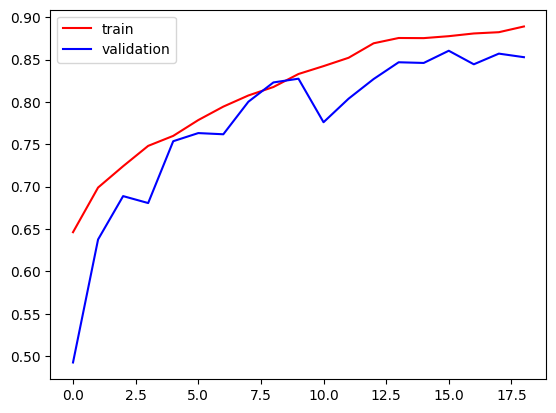

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red' , label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

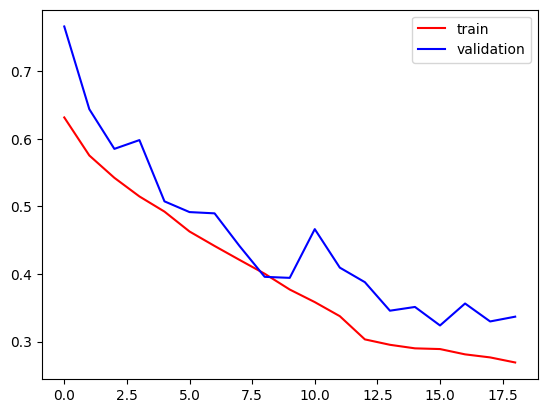

In [20]:
plt.plot(history.history['loss'], color='red' , label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

# Prediction on test data

In [26]:
TEST_DIR = "/kaggle/working/dogs-vs-cats/test/test1"
IMG_SIZE = 160     # same as training
BATCH_SIZE = 32


In [27]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,      
    labels=None
)


Found 12500 files.


In [29]:
import os

image_files = sorted(
    [f for f in os.listdir(TEST_DIR) if f.endswith(".jpg")],
    key=lambda x: int(x.split(".")[0])
)

image_ids = [int(f.split(".")[0]) for f in image_files]


In [31]:
predictions = model.predict(test_ds)
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)


391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step


In [32]:
predictions = model.predict(test_ds)
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)


391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step


In [33]:
print(image_ids[:5])
print(predicted_labels[:5])
print(len(image_ids), len(predicted_labels))


[1, 2, 3, 4, 5]
[1 0 0 1 1]
12500 12500


In [34]:

label_map = {0: "cat", 1: "dog"}


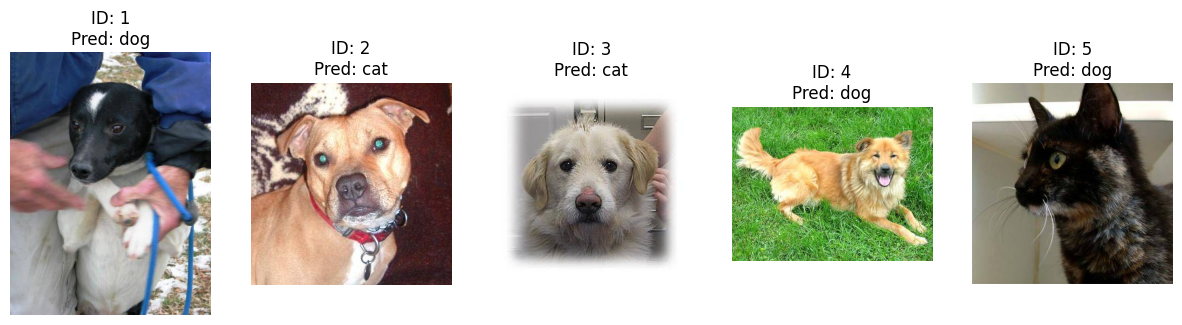

In [35]:
import matplotlib.pyplot as plt
import os

# show first N images
N = 5

plt.figure(figsize=(15, 5))

for i in range(N):
    img_path = os.path.join(TEST_DIR, image_files[i])
    img = plt.imread(img_path)

    plt.subplot(1, N, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"ID: {image_ids[i]}\nPred: {label_map[predicted_labels[i]]}")

plt.show()


In [36]:
print(predictions[:5].reshape(-1))


[0.57774216 0.11078047 0.05068561 0.9151642  0.9195539 ]


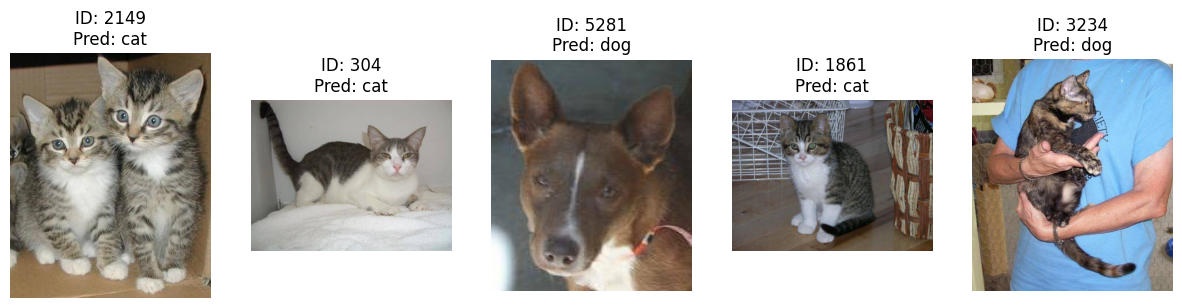

In [39]:
import random

indices = random.sample(range(len(image_files)), 5)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    img_path = os.path.join(TEST_DIR, image_files[idx])
    img = plt.imread(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"ID: {image_ids[idx]}\nPred: {label_map[predicted_labels[idx]]}")

plt.show()


# The CNN trained from scratch achieved strong performance; however, deeper architectures and pretrained models are expected to generalize better by leveraging richer feature representations.